In [28]:
import sys, os

sys.path.append(os.path.join(os.getcwd(),'..'))

from src.instance import Instance
from src.solution import Solution
from src.utils import show_solution, solution_compare_plot

In [29]:
import pandas as pd
import numpy as np

In [30]:
runs_df = pd.read_csv('../results/runs.csv')
runs_df

,instance,profile,run,iteration,total_iterations,cost,k,optimal_cost,optimal_k,elapsed,routes
0,A-n45-k7,NN,0,0,7955,1944.989093,7,1146.0,7,0.017107,"[[0, 13, 7, 16, 35, 26, 38, 32, 8, 9, 21, 0], ..."
1,A-n45-k7,NN,0,1,7955,1902.544737,7,1146.0,7,0.033622,"[[0, 32, 29, 17, 44, 14, 0], [0, 21, 12, 26, 3..."
2,A-n45-k7,NN,0,2,7955,1822.959824,7,1146.0,7,0.049780,"[[0, 10, 11, 44, 37, 33, 0], [0, 32, 1, 17, 25..."
3,A-n45-k7,NN,0,5,7955,1783.534268,7,1146.0,7,0.097736,"[[0, 7, 20, 18, 5, 31, 24, 14, 0], [0, 37, 30,..."
4,A-n45-k7,NN,0,18,7955,1778.165891,7,1146.0,7,0.246899,"[[0, 6, 27, 19, 31, 36, 3, 0], [0, 32, 9, 41, ..."
...,...,...,...,...,...,...,...,...,...,...,...
8939,P-n50-k10,HAS-5,4,746,7143,730.458830,10,696.0,10,11.822824,"[[0, 8, 13, 19, 14, 35, 7, 0], [0, 4, 48, 47, ..."
8940,P-n50-k10,HAS-5,4,748,7143,730.458830,10,696.0,10,11.852352,"[[0, 31, 25, 18, 24, 16, 0], [0, 4, 48, 47, 21..."
8941,P-n50-k10,HAS-5,4,749,7143,730.458830,10,696.0,10,11.867810,"[[0, 17, 40, 12, 26, 0], [0, 4, 48, 47, 21, 0]..."
8942,P-n50-k10,HAS-5,4,750,7143,730.458830,10,696.0,10,11.886238,"[[0, 34, 46, 27, 29, 45, 0], [0, 4, 48, 47, 21..."


In [31]:
ipr_df = runs_df[['instance','profile','run']].drop_duplicates().reset_index(drop=True)
ipr_df

,instance,profile,run
0,A-n45-k7,NN,0
1,A-n45-k7,NN,1
2,A-n45-k7,NN,2
3,A-n45-k7,NN,3
4,A-n45-k7,NN,4
...,...,...,...
345,P-n50-k10,HAS-5,0
346,P-n50-k10,HAS-5,1
347,P-n50-k10,HAS-5,2
348,P-n50-k10,HAS-5,3


In [32]:
idx_min_costo = runs_df.groupby(['instance','profile','run'])['cost'].idxmin()
df = runs_df.loc[idx_min_costo].sort_index()
df['err'] = (df['cost'] - df['optimal_cost']) / df['optimal_cost']

df

,instance,profile,run,iteration,total_iterations,cost,k,optimal_cost,optimal_k,elapsed,routes,err
8,A-n45-k7,NN,0,289,7955,1618.271625,7,1146.0,7,3.405968,"[[0, 35, 4, 38, 39, 32, 13, 18, 0], [0, 21, 12...",0.412104
19,A-n45-k7,NN,1,5990,7955,1645.973809,7,1146.0,7,69.785952,"[[0, 39, 12, 35, 21, 44, 14, 0], [0, 32, 9, 2,...",0.436277
27,A-n45-k7,NN,2,2861,7955,1632.608207,7,1146.0,7,33.390445,"[[0, 41, 27, 44, 3, 2, 26, 39, 0], [0, 9, 15, ...",0.424614
39,A-n45-k7,NN,3,4449,7955,1622.861462,7,1146.0,7,54.097138,"[[0, 20, 42, 23, 25, 15, 10, 0], [0, 26, 34, 3...",0.416109
52,A-n45-k7,NN,4,6728,7955,1592.904119,7,1146.0,7,82.567708,"[[0, 44, 33, 11, 3, 28, 0], [0, 21, 6, 4, 34, ...",0.389969
...,...,...,...,...,...,...,...,...,...,...,...,...
8805,P-n50-k10,HAS-5,0,885,7143,722.450294,10,696.0,10,14.313508,"[[0, 13, 15, 20, 37, 36, 5, 0], [0, 4, 27, 46,...",0.038003
8836,P-n50-k10,HAS-5,1,506,7143,707.030137,10,696.0,10,8.801492,"[[0, 14, 11, 38, 0], [0, 4, 45, 29, 27, 34, 0]...",0.015848
8871,P-n50-k10,HAS-5,2,316,7143,714.015607,10,696.0,10,5.220131,"[[0, 8, 19, 14, 7, 26, 0], [0, 4, 30, 2, 6, 0]...",0.025884
8900,P-n50-k10,HAS-5,3,5072,7143,730.251609,10,696.0,10,78.803922,"[[0, 22, 28, 21, 36, 47, 0], [0, 26, 12, 32, 4...",0.049212


In [33]:
import seaborn as sns

In [34]:
idx_min_costo2 = runs_df.groupby(['instance','profile'])['cost'].idxmin()
df2 = runs_df.loc[idx_min_costo2].sort_index()
df2['err'] = (df2['cost'] - df2['optimal_cost']) / df2['optimal_cost']
df2

,instance,profile,run,iteration,total_iterations,cost,k,optimal_cost,optimal_k,elapsed,routes,err
52,A-n45-k7,NN,4,6728,7955,1592.904119,7,1146.0,7,82.567708,"[[0, 44, 33, 11, 3, 28, 0], [0, 21, 6, 4, 34, ...",0.389969
116,A-n45-k7,AS,2,7062,7955,1175.602173,7,1146.0,7,84.695558,"[[0, 5, 22, 30, 37, 1, 42, 0], [0, 32, 13, 18,...",0.025831
234,A-n45-k7,HAS,2,7062,7955,1175.602173,7,1146.0,7,96.995312,"[[0, 22, 5, 30, 37, 1, 42, 0], [0, 32, 13, 18,...",0.025831
406,A-n45-k7,HAS-SAV,4,7029,7955,1181.058834,7,1146.0,7,96.126707,"[[0, 22, 5, 30, 37, 1, 42, 0], [0, 12, 2, 4, 2...",0.030592
435,A-n45-k7,HAS-CAP,0,4395,7955,1178.184369,7,1146.0,7,59.600506,"[[0, 38, 17, 23, 25, 15, 10, 8, 0], [0, 12, 2,...",0.028084
...,...,...,...,...,...,...,...,...,...,...,...,...
8181,P-n50-k10,HAS,0,4531,7143,710.150086,10,696.0,10,69.875714,"[[0, 3, 44, 32, 9, 0], [0, 26, 12, 40, 17, 0],...",0.020331
8419,P-n50-k10,HAS-SAV,3,6242,7143,712.401226,10,696.0,10,97.801472,"[[0, 48, 5, 37, 20, 15, 13, 0], [0, 45, 29, 27...",0.023565
8528,P-n50-k10,HAS-CAP,1,6985,7143,709.347874,10,696.0,10,106.561699,"[[0, 1, 43, 42, 41, 23, 49, 24, 0], [0, 4, 34,...",0.019178
8685,P-n50-k10,HAS-1,1,2057,7143,708.292091,10,696.0,10,31.641150,"[[0, 11, 14, 19, 35, 0], [0, 4, 45, 29, 13, 27...",0.017661


In [35]:
min_,mean_, std_, k_, opt_, opt_k, imean_, tmean_,imax_ = (
	df.groupby(['instance','profile'])['cost'].min(),
	df.groupby(['instance','profile'])['cost'].mean(),
	df.groupby(['instance','profile'])['cost'].std(),
	df.groupby(['instance','profile'])['k'].min(),
	df.groupby(['instance','profile'])['optimal_cost'].first(),
	df.groupby(['instance','profile'])['optimal_k'].first(),
	df.groupby(['instance','profile'])['iteration'].mean(),
	df.groupby(['instance','profile'])['elapsed'].mean(),
	df.groupby(['instance','profile'])['total_iterations'].first()


)

df0 = min_.reset_index()
df0['mean'] = mean_.reset_index()['cost']
df0['std'] = std_.reset_index()['cost']
df0['k'] = k_.reset_index()['k']
df0['opt_cost'] = opt_.reset_index()['optimal_cost']
df0['opt_k'] = opt_k.reset_index()['optimal_k']
df0['err'] = (df0['cost'] - df0['opt_cost']) / df0['opt_cost']
err_mean = df0['err_mean'] = (df0['mean'] - df0['opt_cost']) / df0['opt_cost']
df0['it_mean'] = imean_.reset_index()['iteration']
df0['time_mean'] = tmean_.reset_index()['elapsed']
df0['it_max'] = imax_.reset_index()['total_iterations']
eff = df0['efficiency'] = (df0['it_max'] - df0['it_mean']) / df0['it_max']

acc = (1 - df0['err_mean']) 
df0['performance'] = 1 - 2 * ( err_mean * eff) / (err_mean + eff)
df0

,instance,profile,cost,mean,std,k,opt_cost,opt_k,err,err_mean,it_mean,time_mean,it_max,efficiency,performance
0,A-n45-k7,AS,1175.602173,1181.857342,5.623607,7,1146.0,7,0.025831,0.031289,5843.2,69.451442,7955,0.265468,0.944020
1,A-n45-k7,HAS,1175.602173,1181.857342,5.623607,7,1146.0,7,0.025831,0.031289,5843.2,80.411037,7955,0.265468,0.944020
2,A-n45-k7,HAS-1,1196.358660,1197.799618,1.746385,7,1146.0,7,0.043943,0.045200,5608.0,74.580221,7955,0.295035,0.921609
3,A-n45-k7,HAS-5,1185.321288,1193.622403,8.523098,7,1146.0,7,0.034312,0.041555,4042.2,55.122590,7955,0.491867,0.923364
4,A-n45-k7,HAS-CAP,1178.184369,1192.164789,7.878173,7,1146.0,7,0.028084,0.040283,3696.0,49.706751,7955,0.535387,0.925071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,P-n50-k10,HAS-1,708.292091,723.628694,16.306164,10,696.0,10,0.017661,0.039696,2824.6,43.771588,7143,0.604564,0.925499
66,P-n50-k10,HAS-5,707.030137,720.841295,10.258874,10,696.0,10,0.015848,0.035692,1506.2,23.811404,7143,0.789136,0.931706
67,P-n50-k10,HAS-CAP,709.347874,714.128540,3.265865,10,696.0,10,0.019178,0.026047,4559.0,70.012023,7143,0.361753,0.951405
68,P-n50-k10,HAS-SAV,712.401226,726.655117,12.705745,10,696.0,10,0.023565,0.044045,5212.8,81.220400,7143,0.270223,0.924256


[Text(0.5, 0, 'Errore medio'),
 Text(0, 0.5, 'Efficienza'),
 Text(0.5, 1.0, 'skibidi')]

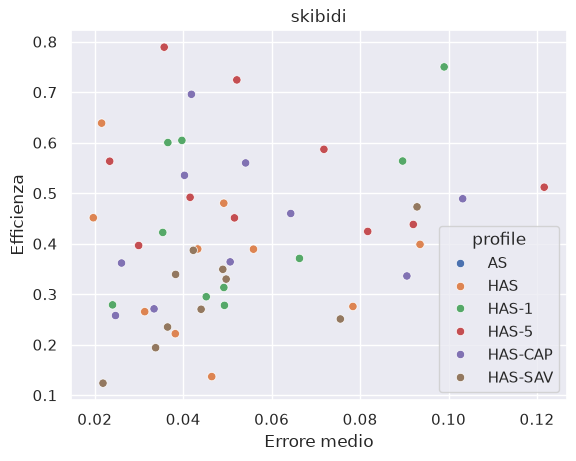

In [36]:
import matplotlib.pyplot as plt

sns.set_theme()

ax = sns.scatterplot(df0[df0['profile'] !='NN'], x='err_mean', y='efficiency', hue='profile')
ax.set(
	xlabel='Errore medio',
	ylabel="Efficienza",
	title='skibidi'
)


[Text(0.5, 0, 'Profilo'),
 Text(0, 0.5, 'Errore medio'),
 Text(0.5, 1.0, 'skibidi')]

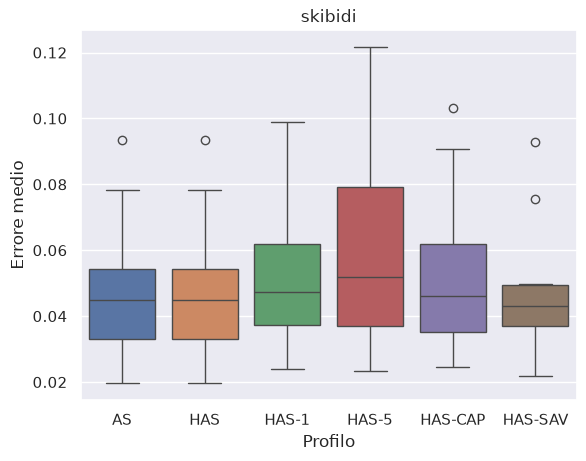

In [37]:
ax = sns.boxplot(df0[df0['profile'] != 'NN'], x='profile', y='err_mean', hue='profile')
ax.set(
	xlabel='Profilo',
	ylabel="Errore medio",
	title='skibidi'
)


[Text(0.5, 0, 'Profilo'),
 Text(0, 0.5, 'Efficienza'),
 Text(0.5, 1.0, 'skibidi')]

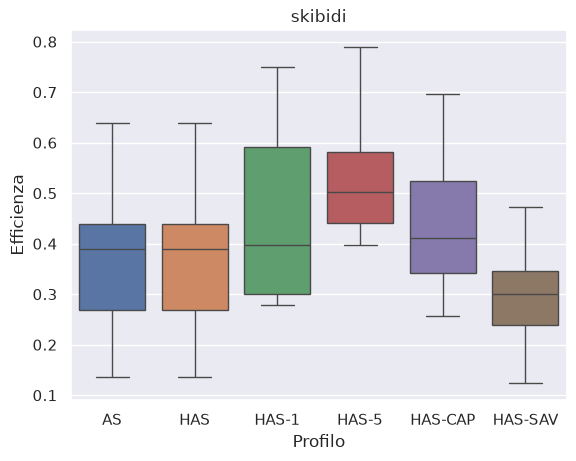

In [38]:
ax = sns.boxplot(df0[df0['profile'] != 'NN'], x='profile', y='efficiency', hue='profile')
ax.set(
	xlabel='Profilo',
	ylabel="Efficienza",
	title='skibidi'
)

[Text(0.5, 0, 'Profilo'),
 Text(0, 0.5, 'Performance'),
 Text(0.5, 1.0, 'skibidi')]

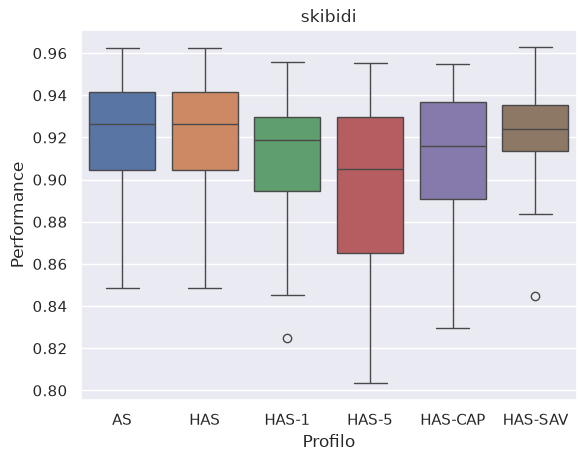

In [39]:
ax = sns.boxplot(df0[df0['profile'] != 'NN'], x='profile', y='performance', hue='profile')
ax.set(
	xlabel='Profilo',
	ylabel="Performance",
	title='skibidi'
)


In [40]:
df_best = (
	df0.sort_values('cost')
		.drop_duplicates(subset=['instance'],keep='first')
		.sort_values(['instance'])
)

df_best[['instance','profile','opt_cost','cost','err','mean','err_mean','std', 'it_mean','it_max' ]]


,instance,profile,opt_cost,cost,err,mean,err_mean,std,it_mean,it_max
1,A-n45-k7,HAS,1146.0,1175.602173,0.025831,1181.857342,0.031289,5.623607,5843.2,7955
10,A-n60-k9,HAS-5,1354.0,1372.940252,0.013988,1394.510559,0.029919,17.972083,3580.6,5933
14,A-n80-k10,AS,1763.0,1824.056851,0.034632,1839.299220,0.043278,15.814017,2704.6,4431
24,B-n56-k7,HAS-5,707.0,755.620465,0.068770,764.776641,0.081721,8.800126,3663.6,6364
28,B-n66-k9,AS,1316.0,1338.715937,0.017261,1341.875674,0.019662,2.384198,2954.0,5385
38,B-n78-k10,HAS-5,1221.0,1273.119092,0.042686,1283.979425,0.051580,9.994897,2495.0,4546
47,E-n101-k14,HAS-SAV,1071.0,1141.045720,0.065402,1151.890571,0.075528,8.940231,2621.6,3500
51,E-n76-k8,HAS-1,735.0,758.968669,0.032610,771.246456,0.049315,10.775187,3369.8,4667
58,P-n101-k4,HAS-1,681.0,697.041627,0.023556,705.088896,0.035373,4.838693,2021.8,3500
66,P-n50-k10,HAS-5,696.0,707.030137,0.015848,720.841295,0.035692,10.258874,1506.2,7143


In [41]:

df_exp = df_best.copy()
roundFn = lambda x: np.round(x,2)

df_exp['cost'] = df_exp['cost'].apply(roundFn)
df_exp['mean'] = df_exp['mean'].apply(roundFn)
df_exp['std'] = df_exp['std'].apply(roundFn)
percentFn = lambda x: "{:.3f}%".format(x*100)
df_exp['err'] = df_best['err'].apply(percentFn)
df_exp['err_mean'] = df_best['err_mean'].apply(percentFn)
df_exp[['instance', 'profile','opt_cost', 'cost', 'err', 'mean', 'err_mean', 'std', 'k', 'it_mean']]

,instance,profile,opt_cost,cost,err,mean,err_mean,std,k,it_mean
1,A-n45-k7,HAS,1146.0,1175.60,2.583%,1181.86,3.129%,5.62,7,5843.2
10,A-n60-k9,HAS-5,1354.0,1372.94,1.399%,1394.51,2.992%,17.97,9,3580.6
14,A-n80-k10,AS,1763.0,1824.06,3.463%,1839.30,4.328%,15.81,10,2704.6
24,B-n56-k7,HAS-5,707.0,755.62,6.877%,764.78,8.172%,8.80,7,3663.6
28,B-n66-k9,AS,1316.0,1338.72,1.726%,1341.88,1.966%,2.38,9,2954.0
38,B-n78-k10,HAS-5,1221.0,1273.12,4.269%,1283.98,5.158%,9.99,10,2495.0
47,E-n101-k14,HAS-SAV,1071.0,1141.05,6.540%,1151.89,7.553%,8.94,14,2621.6
51,E-n76-k8,HAS-1,735.0,758.97,3.261%,771.25,4.931%,10.78,8,3369.8
58,P-n101-k4,HAS-1,681.0,697.04,2.356%,705.09,3.537%,4.84,4,2021.8
66,P-n50-k10,HAS-5,696.0,707.03,1.585%,720.84,3.569%,10.26,10,1506.2


[Text(0.5, 0, 'Profilo'),
 Text(0, 0.5, 'Errore'),
 Text(0.5, 1.0, 'Distribuzione errore')]

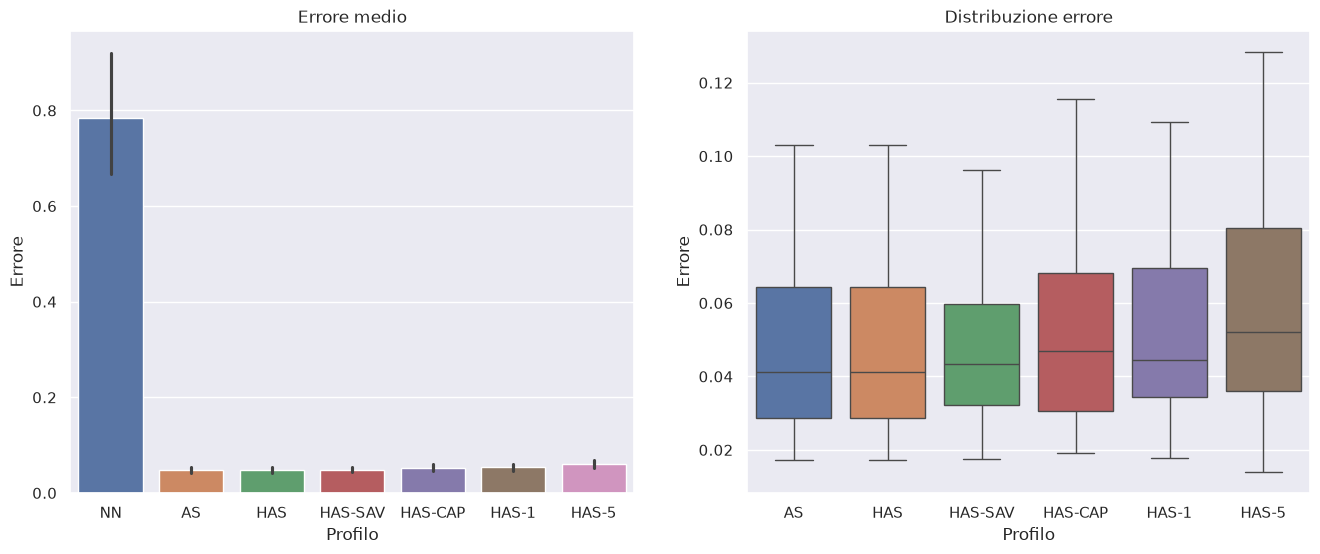

In [42]:

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,6))

sns.barplot(df, x='profile', y='err', hue='profile', ax = ax1)

ax1.set(
	xlabel='Profilo',
	ylabel="Errore",
	title="Errore medio"

)

sns.boxplot(df[df['profile'] != 'NN'], x='profile', y='err', hue='profile', ax= ax2)

ax2.set(
	xlabel='Profilo',
	ylabel="Errore",
	title="Distribuzione errore"
)

In [43]:
df['time'] = df['iteration'] / df['total_iterations']
df

,instance,profile,run,iteration,total_iterations,cost,k,optimal_cost,optimal_k,elapsed,routes,err,time
8,A-n45-k7,NN,0,289,7955,1618.271625,7,1146.0,7,3.405968,"[[0, 35, 4, 38, 39, 32, 13, 18, 0], [0, 21, 12...",0.412104,0.036329
19,A-n45-k7,NN,1,5990,7955,1645.973809,7,1146.0,7,69.785952,"[[0, 39, 12, 35, 21, 44, 14, 0], [0, 32, 9, 2,...",0.436277,0.752986
27,A-n45-k7,NN,2,2861,7955,1632.608207,7,1146.0,7,33.390445,"[[0, 41, 27, 44, 3, 2, 26, 39, 0], [0, 9, 15, ...",0.424614,0.359648
39,A-n45-k7,NN,3,4449,7955,1622.861462,7,1146.0,7,54.097138,"[[0, 20, 42, 23, 25, 15, 10, 0], [0, 26, 34, 3...",0.416109,0.559271
52,A-n45-k7,NN,4,6728,7955,1592.904119,7,1146.0,7,82.567708,"[[0, 44, 33, 11, 3, 28, 0], [0, 21, 6, 4, 34, ...",0.389969,0.845757
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8805,P-n50-k10,HAS-5,0,885,7143,722.450294,10,696.0,10,14.313508,"[[0, 13, 15, 20, 37, 36, 5, 0], [0, 4, 27, 46,...",0.038003,0.123898
8836,P-n50-k10,HAS-5,1,506,7143,707.030137,10,696.0,10,8.801492,"[[0, 14, 11, 38, 0], [0, 4, 45, 29, 27, 34, 0]...",0.015848,0.070839
8871,P-n50-k10,HAS-5,2,316,7143,714.015607,10,696.0,10,5.220131,"[[0, 8, 19, 14, 7, 26, 0], [0, 4, 30, 2, 6, 0]...",0.025884,0.044239
8900,P-n50-k10,HAS-5,3,5072,7143,730.251609,10,696.0,10,78.803922,"[[0, 22, 28, 21, 36, 47, 0], [0, 26, 12, 32, 4...",0.049212,0.710066


<Axes: xlabel='time', ylabel='err'>

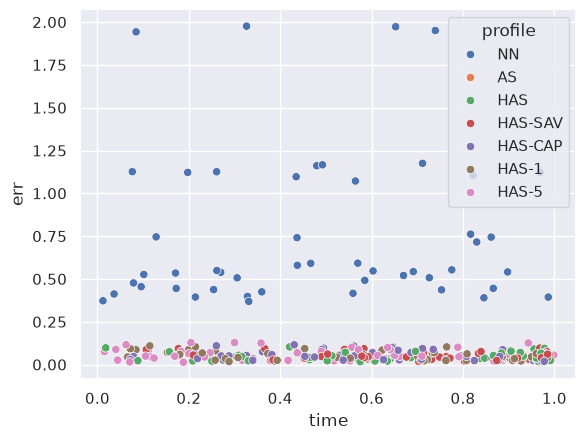

In [44]:
sns.scatterplot(df, x='time', y='err', hue='profile')

In [45]:
df0

,instance,profile,cost,mean,std,k,opt_cost,opt_k,err,err_mean,it_mean,time_mean,it_max,efficiency,performance
0,A-n45-k7,AS,1175.602173,1181.857342,5.623607,7,1146.0,7,0.025831,0.031289,5843.2,69.451442,7955,0.265468,0.944020
1,A-n45-k7,HAS,1175.602173,1181.857342,5.623607,7,1146.0,7,0.025831,0.031289,5843.2,80.411037,7955,0.265468,0.944020
2,A-n45-k7,HAS-1,1196.358660,1197.799618,1.746385,7,1146.0,7,0.043943,0.045200,5608.0,74.580221,7955,0.295035,0.921609
3,A-n45-k7,HAS-5,1185.321288,1193.622403,8.523098,7,1146.0,7,0.034312,0.041555,4042.2,55.122590,7955,0.491867,0.923364
4,A-n45-k7,HAS-CAP,1178.184369,1192.164789,7.878173,7,1146.0,7,0.028084,0.040283,3696.0,49.706751,7955,0.535387,0.925071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,P-n50-k10,HAS-1,708.292091,723.628694,16.306164,10,696.0,10,0.017661,0.039696,2824.6,43.771588,7143,0.604564,0.925499
66,P-n50-k10,HAS-5,707.030137,720.841295,10.258874,10,696.0,10,0.015848,0.035692,1506.2,23.811404,7143,0.789136,0.931706
67,P-n50-k10,HAS-CAP,709.347874,714.128540,3.265865,10,696.0,10,0.019178,0.026047,4559.0,70.012023,7143,0.361753,0.951405
68,P-n50-k10,HAS-SAV,712.401226,726.655117,12.705745,10,696.0,10,0.023565,0.044045,5212.8,81.220400,7143,0.270223,0.924256


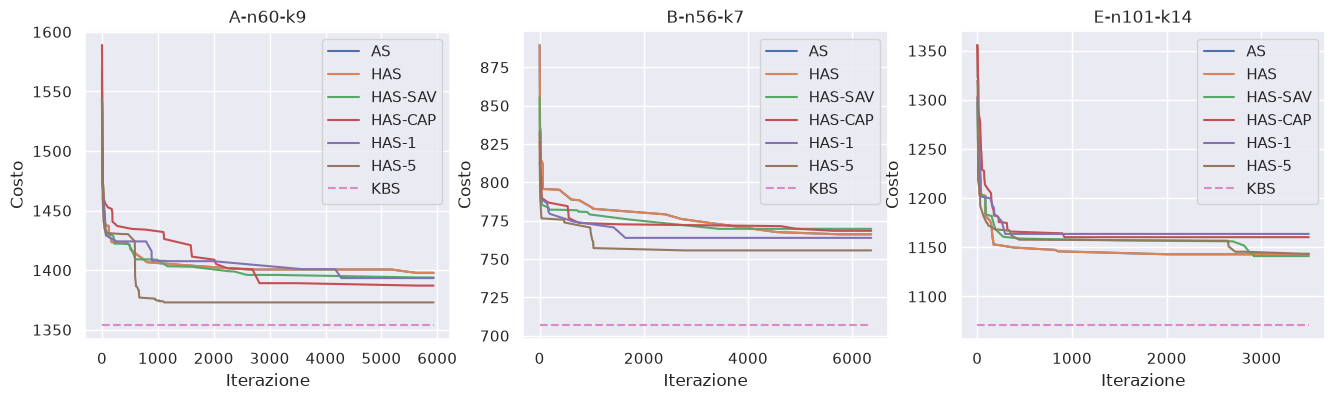

In [ ]:
instances = [
	'A-n60-k9',
	'B-n56-k7',
	'E-n101-k14'
]
fig, axes = plt.subplots(1,3, figsize=(16,4))
for name, ax in zip(instances, axes ):
	idf = df[df['instance'] == name]
	bks = idf.iloc[0].optimal_cost
	total_iterations = idf.iloc[0].total_iterations
	#run, profile = idf.loc[idf['cost'].idxmin()][['run','profile']]
	#idf = runs_df[
	#		(runs_df['instance'] == instance) 
	#	& (runs_df['run'] == run) 
	#	& (runs_df['profile'] == profile)
	#]
	idx = idf.groupby(['profile'])['cost'].idxmin()
	idf2 = idf.loc[idx][['instance','profile','run']]
	idf2 = idf2[idf2['profile'] != 'NN']
	idf2 = runs_df.merge(idf2)

	endp = idf2.groupby(['profile'])['cost'].idxmin()

	endp = idf2.loc[endp]
	endp['iteration'] = endp['total_iterations']
	idf2 = pd.concat([idf2, endp])
	sns.lineplot(idf2, x='iteration', y='cost', hue='profile', ax = ax)
	#ax.axhline(bks, ls='--', c='purple')

	ax.set(
		title=name,
		xlabel='Iterazione',
		ylabel='Costo'
	)
	ax.plot([0, total_iterations], [bks,bks], '--', label="KBS")
	ax.legend()
	#
fig.tight_layout()

plt.show()
	#display(idf2)

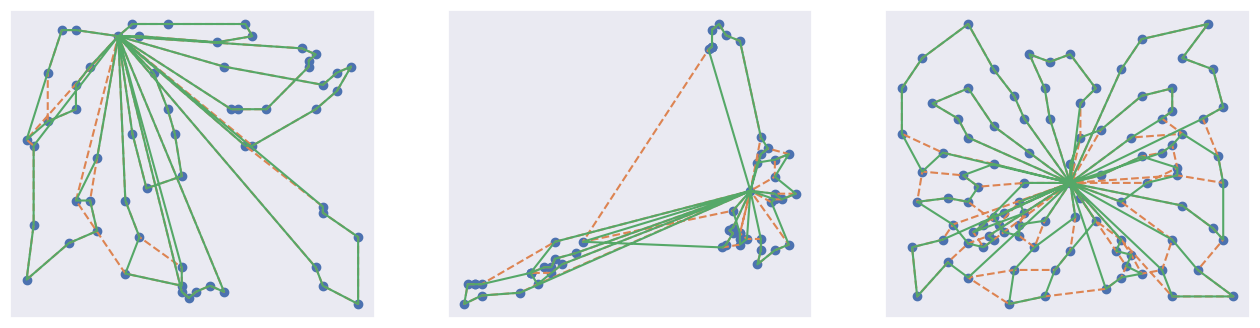

In [48]:
import json

import matplotlib.pyplot as plt
instances = [
	'A-n60-k9',
	'B-n56-k7',
	'E-n101-k14'
]
fig, axes = plt.subplots(1,3, figsize=(16,4))
for name, ax in zip(instances, axes ):
	
	idf = runs_df[runs_df['instance'] == name]
	sol = idf.sort_values('cost').iloc[0]
	cost, routes = sol['cost'], json.loads(sol['routes'])
	instance = Instance.load_vrp(f'../instances/{name}.vrp')
	best_sol = Solution.load_sol(f'../instances/sol/{name}.sol', instance, lenient=True)
	my_sol = Solution(routes, cost)
	solution_compare_plot(instance, best_sol, my_sol, ax)
	ax.set_xticks([])
	ax.set_yticks([])

	#
plt.show()
	#display(idf2)